In [1]:
import torch
from argparse import Namespace
from ay2.tools.text._phonemes import Phonemer_Tokenizer_Recombination
from pandas import Series

torch.serialization.add_safe_globals([
    Namespace,
    Phonemer_Tokenizer_Recombination,
    Series,
])
print("✅ Added safe globals for torch.load (Namespace, Phonemer_Tokenizer_Recombination, Series)")


/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/librosa/core/intervals.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._registe

✅ Added safe globals for torch.load (Namespace, Phonemer_Tokenizer_Recombination, Series)


In [2]:
import torch

# Monkey-patch torch.load to default to weights_only=False (Torch 2.6+ defaults to True)
_orig_torch_load = torch.load

def _torch_load_no_weights_only(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _orig_torch_load(*args, **kwargs)

torch.load = _torch_load_no_weights_only
print("✅ Patched torch.load to default weights_only=False for this kernel session.")


✅ Patched torch.load to default weights_only=False for this kernel session.


In [3]:
from phoneme_GAT.modules import Phoneme_GAT_lit
import torch
import pandas as pd


/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [5]:
import os

def load_hf_token(path="secret.txt"):
    if os.path.exists(path):
        with open(path, "r") as f:
            return f.read().strip()
    return None

DATASET_NAME   = "Bisher/ASVspoof_2019_LA"
CACHE_DIR      = "./data/asvspoof_2019_la"
SUBSET_SAMPLES = None

HF_TOKEN = load_hf_token()

print("Dataset name    :", DATASET_NAME)
print("Cache dir       :", CACHE_DIR)
print("Subset samples  :", SUBSET_SAMPLES)
print("HF token present:", "✅ Yes" if HF_TOKEN else "❌ No (use secret.txt or HF login)")


Dataset name    : Bisher/ASVspoof_2019_LA
Cache dir       : ./data/asvspoof_2019_la
Subset samples  : None
HF token present: ✅ Yes


In [6]:
from loader import get_train_dataloader, get_eval_dataloader

train_dataloader = get_train_dataloader(
    source="hf",
    hf_name=DATASET_NAME,
    batch_size=3,
    hf_cache_dir=CACHE_DIR,
    limit=1000,
    hf_token=HF_TOKEN if HF_TOKEN else None,
    drop_last=True,         # ✅ demo fix for partial batch size weirdness
)

val_dataloader = get_eval_dataloader(
    source="hf",
    split="validation",
    hf_name=DATASET_NAME,
    batch_size=3,
    hf_cache_dir=CACHE_DIR,
    limit=500,
    hf_token=HF_TOKEN if HF_TOKEN else None,
)

print("✅ train batches:", len(train_dataloader))
print("✅ val batches  :", len(val_dataloader))


/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/loader.py:18: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("sox_io")


✓ HF Bisher/ASVspoof_2019_LA:train [train] → 1000 samples (balance=True)
✓ HF Bisher/ASVspoof_2019_LA:validation [eval] → 500 samples (balance=True)
✅ train batches: 333
✅ val batches  : 167


In [7]:
from argparse import Namespace

cfg = Namespace(
    PhonemeGAT=Namespace(
        backbone="wavlm",
        use_raw=False,
        use_GAT=True,
        n_edges=10,
        use_aug=True,
        use_pool=True,
        use_clip=True,
    )
)
print("✅ cfg ready")


✅ cfg ready


In [8]:
import torch
import pandas as pd

CKPT_PATH = "good_run_full.ckpt"
CSV_OUT   = "val_logits.csv"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) init model
model = Phoneme_GAT_lit(cfg=cfg).to(device)
model.eval()

# 2) load checkpoint (monkey patch forces weights_only=False)
ckpt = torch.load(CKPT_PATH, map_location=device)

# lightning ckpt usually has ckpt["state_dict"]
state = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
model.load_state_dict(state, strict=False)

print("✅ loaded weights from:", CKPT_PATH)

# 3) run validation forward + collect logits/labels
rows = []
with torch.no_grad():
    for batch_idx, batch in enumerate(val_dataloader):
        # move tensors to device
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        if "sample_rate" not in batch:
            batch["sample_rate"] = 16000

        out = model._shared_pred(batch=batch, batch_idx=batch_idx)
        logits = out["logit"].squeeze()                 # pre-sigmoid
        labels = batch["label"].squeeze().long()
        probs  = torch.sigmoid(logits)                  # post-sigmoid

        for y, l, p in zip(labels.detach().cpu().view(-1),
                           logits.detach().cpu().view(-1),
                           probs.detach().cpu().view(-1)):
            rows.append({
                "true_label": int(y),
                "logit_pre_sigmoid": float(l),
                "prob_post_sigmoid": float(p),
            })

df = pd.DataFrame(rows)
df.to_csv(CSV_OUT, index=False)
print("✅ wrote:", CSV_OUT, "rows:", len(df))
df.head()


Now, load vocab json files from /lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/vocab_phoneme Please make sure the vocab files are correct
Load WavLM model!!!!!!!


Some weights of WavLMForCTC were not initialized from the model checkpoint at microsoft/wavlm-base and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'lm_head.weight', 'lm_head.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([687, 768])
✅ loaded weights from: good_run_full.ckpt
✅ wrote: val_logits.csv rows: 500


,true_label,logit_pre_sigmoid,prob_post_sigmoid
0,0,10.989480,0.999983
1,1,12.842402,0.999997
2,0,11.100542,0.999985
3,0,11.379323,0.999989
4,1,11.529484,0.999990


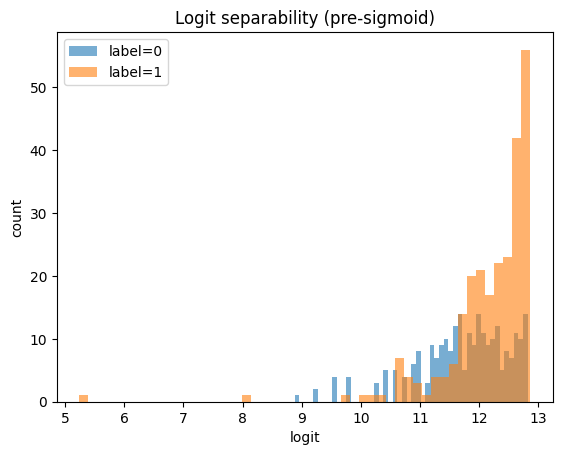

In [9]:
import matplotlib.pyplot as plt

df0 = df[df["true_label"] == 0]["logit_pre_sigmoid"]
df1 = df[df["true_label"] == 1]["logit_pre_sigmoid"]

plt.figure()
plt.hist(df0, bins=50, alpha=0.6, label="label=0")
plt.hist(df1, bins=50, alpha=0.6, label="label=1")
plt.title("Logit separability (pre-sigmoid)")
plt.xlabel("logit")
plt.ylabel("count")
plt.legend()
plt.show()
